# Data Visualization Ethics Challenge

In this activity, you’ll work with a simple dataset and examine two deliberately bad charts.  
Each one ignores multiple best practices for ethical and effective visualization.

Your job is to:

1. Review each chart and note at least three issues you see.  
2. Create a new chart (or charts) that present the data clearly, accurately, and honestly.  
3. Include clear labels, a cited data source, and a descriptive but neutral title.

**Remember:** Strong visualizations tell the truth, provide context, and avoid design choices that distort or mislead.


## Step 1: Load the dataset

We’re using a provided CSV file with fictional sales data for a coffee chain.  
No need to modify anything in this cell — just run it so the dataset loads into your notebook.  
Once loaded, take a quick look at the first few rows to get familiar with the columns and values.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

coffee_df = pd.read_csv("fake_coffee_chain_sales.csv")
coffee_df.head()

,Year,Month,Region,Category,Sales,Profit
0,2020,January,East,Espresso,14724,5290.46
1,2020,January,East,Lattes,11948,4138.77
2,2020,January,East,Tea,18660,5959.44
3,2020,January,East,Pastries,11265,2604.46
4,2020,January,East,Beans,8954,2613.22


## Step 2: Review the BAD Charts

Below are two deliberately poor visualizations.  
Your task: Carefully review each and take notes on what you think is wrong, misleading, or just poorly designed.  
Think about chart type, colors, scales, labeling, and whether the chart tells the truth.  


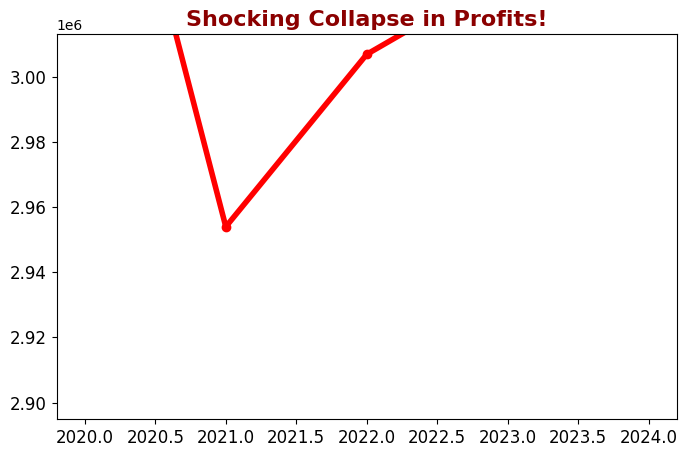

In [5]:
plt.figure(figsize=(8,5))
subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()

# Wrong variable for title, truncated y-axis, misleading color & framing
plt.plot(subset["Year"], subset["Sales"], color="red", linewidth=4, marker="o")
plt.ylim(subset["Sales"].min() * 0.98, subset["Sales"].min() * 1.02)  # extreme truncation
plt.title("Shocking Collapse in Profits!", fontsize=16, fontweight="bold", color="darkred")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


### Write your notes about bad chart #1 here:

## Truncation of Data and ylim
- makes changes look exagerated, as the yaxis is zoomed in
- also makes data points appear to be missing

## Y axis label needed 
- are these sales in millions? context needs to be added

## Decimal Points on the Dates
- confusing and not standard 
- need a label for years (if they are years)

## Scientific Notation in the Upper Left
- "1e6" should be removed 

## Red Color
- The Red on White could be better
- The red color choice also triggers a misleading reaction .. red = bad or loss 

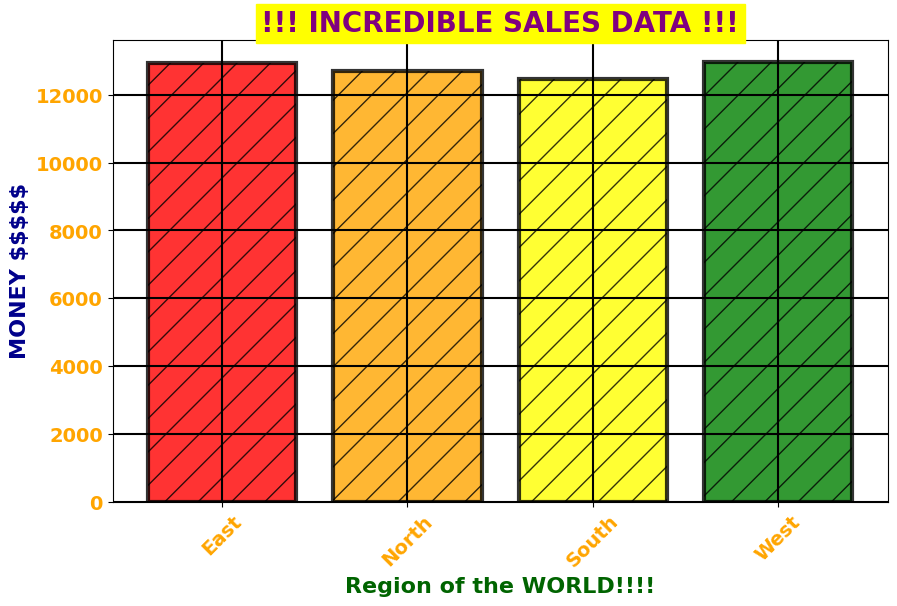

In [8]:
plt.figure(figsize=(10,6))
avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()

colors = ["red","orange","yellow","green","blue","purple"]

plt.bar(avg_sales["Region"], avg_sales["Sales"], 
        color=colors, edgecolor="black", linewidth=3, hatch="/", alpha=0.8)
plt.title("!!! INCREDIBLE SALES DATA !!!", fontsize=20, fontweight="bold", color="purple", backgroundcolor="yellow")
plt.grid(True, which='both', color='black', linestyle='-', linewidth=1.5)
plt.xlabel("Region of the WORLD!!!!", fontsize=16, fontweight="bold", color="darkgreen")
plt.ylabel("MONEY $$$$$", fontsize=16, fontweight="bold", color="darkblue")
plt.xticks(rotation=45, fontsize=14, fontweight="bold", color="orange")
plt.yticks(fontsize=14, fontweight="bold", color="orange")
plt.show()


### Write your notes about bad chart #2 here:
(double click to open this markdown cell and type into it)

## title background color and text color 
- visually unpleasant 
- contrast and colorbliness issues 
- yellow background not needed 

## title overlap into chart
- add padding or space
- removing top and right spines would also be helpful 

## too many lines
- grid lines not needed and add clutter
- diagonal filler lines / hatched lines in bars not needed and appear cluttered

## need context for money label in y axis
- currency used ? 
- ammounts .. actual or in millions, ect
- multiple $ signs misleading

## regions of the world 
- !!! is not needed 
- more context would help 

## color of y and x axis labels 
- low contrast and hard on the eyes 

## color choices of bars
- could use a better pallete 
- looks like there would be issues for color blind individuals 

## could use labels above the bars with specific values
- difficult to tell visually which has the most 

## Step 3: Your Turn – Make It Right

Now it’s your turn to fix things.  

- Start by thinking about a question you want to answer with this dataset.  
- Choose a visualization type that matches your question and the data structure.  
- Apply the best practices from our lessons: clear labeling, appropriate scale, purposeful color, simplicity, and accessibility.  
- Be honest - don’t manipulate the chart to make a point that the data doesn’t support.  

When you’re done, add your chart(s) below. You may create more than one if it helps tell the story better.  


In [15]:
# Your GOOD visualization(s) here

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

coffee_df = pd.read_csv("fake_coffee_chain_sales.csv")
coffee_df.head()

,Year,Month,Region,Category,Sales,Profit
0,2020,January,East,Espresso,14724,5290.46
1,2020,January,East,Lattes,11948,4138.77
2,2020,January,East,Tea,18660,5959.44
3,2020,January,East,Pastries,11265,2604.46
4,2020,January,East,Beans,8954,2613.22


In [9]:
coffee_df.describe()
coffee_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      1200 non-null   int64  
 1   Month     1200 non-null   str    
 2   Region    1200 non-null   str    
 3   Category  1200 non-null   str    
 4   Sales     1200 non-null   int64  
 5   Profit    1200 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 56.4 KB


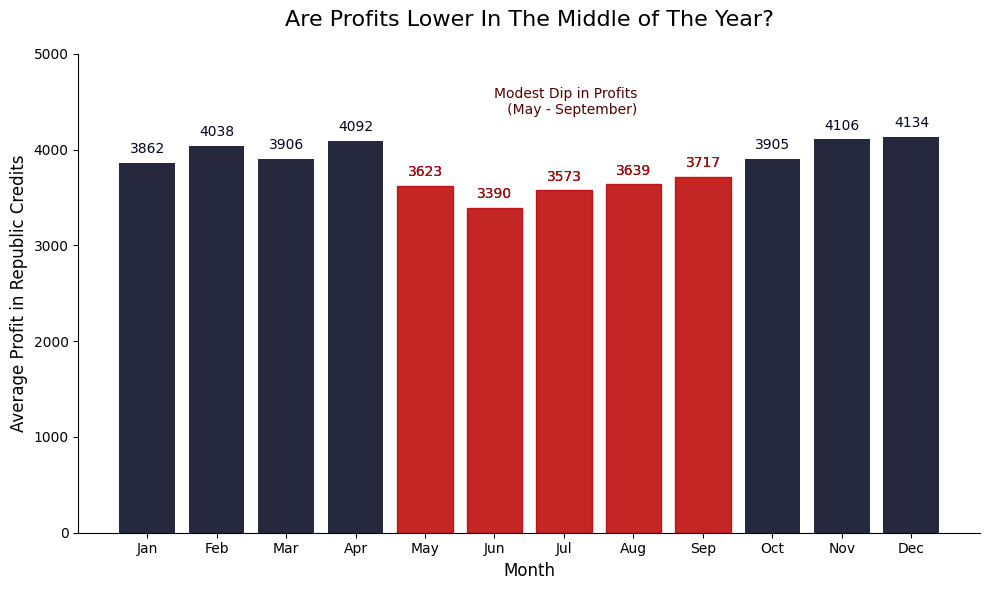

In [100]:
# Average Monthly Profits Across All Reagions & Years
# Is there a Seasonal Trend In Profits? 

import pandas as pd
import matplotlib.pyplot as plt  

deepOcean_Abyss = "#00021B"

month_map = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}  

coffee_df['Month_Num'] = coffee_df['Month'].map(month_map)  
monthly_avg = coffee_df.groupby('Month_Num')['Profit'].mean().sort_index()

plt.figure(figsize=(10, 6))  


bars = plt.bar(monthly_avg.index, monthly_avg.values, color=deepOcean_Abyss, alpha=0.85)  

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

for i, (month, value) in enumerate(monthly_avg.items()):
    ax.text(
    month -0.25, 
    value +100,
    f"{round(value)}",
    color= deepOcean_Abyss
    )
    if 5 <= month <= 9:
        bars[i].set_color("#ba0000")
        ax.text(
        month -0.25, 
        value +100,
        f"{round(value)}",
        color= "#ba0000"
        )  


plt.title("Are Profits Lower In The Middle of The Year?", fontsize=16, pad=20)        
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Profit in Republic Credits", fontsize=12)  
plt.xticks(ticks=range(1,13), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])  
plt.ylim(0, 5000) 


ax.text(
    6, 
    4200,
    "Modest Dip in Profits\n"
    "   (May - September)   \n",
    color="#4d0202"
)

plt.tight_layout()

plt.show()  

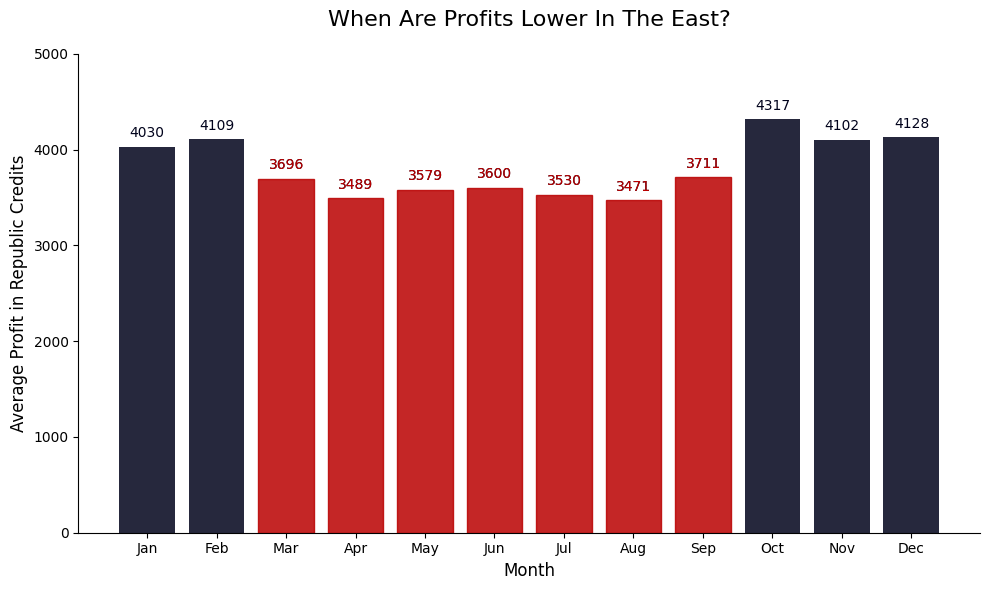

In [101]:
# Is the trend stronger in certain regions? 
# Average Monthly Profits Across All Years in Certain Reagions 
# Is there a Seasonal Trend In Profits? 

# Change select_region variable to see results for a different region ... 
select_region = "East" 

deepOcean_Abyss = "#00021B"

month_map = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}  



coffee_df['Month_Num'] = coffee_df['Month'].map(month_map)  
region_group_df = coffee_df[coffee_df['Region'] == select_region]
monthly_avg = region_group_df.groupby('Month_Num')['Profit'].mean().sort_index()

plt.figure(figsize=(10, 6))  

# red bars only if average profits are average for all months 
bars = plt.bar(monthly_avg.index, monthly_avg.values, color=deepOcean_Abyss, alpha=0.85)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)  


for i, value in enumerate(monthly_avg.values):
    ax.text(
    i+0.75, 
    value +100,
    f"{round(value)}",
    color= deepOcean_Abyss
    )
    if value < monthly_avg.mean():
        bars[i].set_color("#ba0000")
        ax.text(
            i+0.75, 
            value +100,
            f"{round(value)}",
            color= "#ba0000"
        )
    

plt.title(f"When Are Profits Lower In The {select_region}?", fontsize=16, pad=20)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Profit in Republic Credits", fontsize=12)  
plt.xticks(ticks=range(1,13), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])  
plt.ylim(0, 5000) 








plt.tight_layout()

plt.show()  